In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm

import statsmodels.stats.power as smp
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

fingers = ['1', '2', '3', '4', '5']

iti = 1000 # msecs for inter-trial interval
planTime = 2000 # msecs for precue time
feedbackTime = 2000 # msecs for feedback time


total_sub_num = 20
num_sessions = 3
num_blocks_first_session = 4
num_blocks_second_session = 4
num_blocks_third_session = 4
num_blocks_fourth_session = 4
num_trials_per_block = 120
num_trials_baseline = 20

sub_nums = [2, 3, 4, 5, 6, 7, 8, 9, 10]

utils.set_figure_style("1col")
sns.color_palette('colorblind')


[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [2]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')

subjs = subjs[subjs['subNum'].isin(sub_nums)].reset_index(drop=True)


In [3]:
subjs_correct = utils.remove_error_trials(subjs).copy()

subjs_grouped = subjs_correct.groupby(['subNum','block_type']).agg({
    'count': 'sum',
}).reset_index()

subjs_grouped

,subNum,block_type,count
0,2,purturbed,663
1,2,unpurturbed,109
2,3,purturbed,864
3,3,unpurturbed,131
4,4,purturbed,862
5,4,unpurturbed,138
6,5,purturbed,796
7,5,unpurturbed,115
8,6,purturbed,234
9,6,unpurturbed,37


In [4]:
subjs_correct['chord_type'] = subjs_correct.apply(utils.determine_two_finger_chord_type, axis = 1)


In [5]:
def is_index_ring_or_both(row):
    chord_type = row['chord_type']

    if chord_type == 'asymmetric':
        return 'asymmetric'
    elif chord_type == 'symmetric':
        return 'symmetric'
    elif chord_type == 'one_finger':
        index_action = row['chord'][1]
        ring_action = row['chord'][3]
        if index_action == '^' or index_action == 'v':
            return 'index'
        elif ring_action == '^' or ring_action == 'v':
            return 'ring'
        else:
            return 'both'


In [6]:
subjs_correct.columns

Index(['subNum', 'BN', 'TN', 'trial_num_within_chord', 'TotalTrialNum',
       'targetForce1', 'targetForce2', 'targetForce3', 'targetForce4',
       'targetForce5', 'endForce1', 'endForce2', 'endForce3', 'endForce4',
       'endForce5', 'isTargetVisible', 'endForcePurturbed1',
       'endForcePurturbed2', 'endForcePurturbed3', 'endForcePurturbed4',
       'endForcePurturbed5', 'purturbation1', 'purturbation2', 'forceGain',
       'trialCorr', 'trialErrorType', 'num_targets', 'chord', 'day',
       'block_type', 'count', 'chord_type'],
      dtype='str')

In [7]:
subjs_correct['chord_type'] = subjs_correct.apply(is_index_ring_or_both, axis = 1)

In [8]:
subjs_correct['chord_type'].value_counts()

chord_type
index         1688
ring          1616
symmetric     1330
asymmetric    1247
Name: count, dtype: int64

# AutoCov of produced forces

## Unpurturbed Blocks

In [9]:
unpurturbed_blocks = subjs_correct[subjs_correct['block_type'] == 'unpurturbed'].copy()
# unpurturbed_blocks['chord_type'] = unpurturbed_blocks.apply(utils.determine_two_finger_chord_type, axis = 1)


In [10]:
unpurturbed_blocks.head(10)

,subNum,BN,TN,trial_num_within_chord,TotalTrialNum,targetForce1,targetForce2,targetForce3,targetForce4,targetForce5,...,purturbation2,forceGain,trialCorr,trialErrorType,num_targets,chord,day,block_type,count,chord_type
4,2,1,5,5,5,0.0,-2.0,0.0,0.0,0.0,...,0.0,1.0,1,0,1,-v---,1,unpurturbed,1,index
5,2,1,6,6,6,0.0,-2.0,0.0,0.0,0.0,...,0.0,1.0,1,0,1,-v---,1,unpurturbed,1,index
6,2,1,7,7,7,0.0,-2.0,0.0,0.0,0.0,...,0.0,1.0,1,0,1,-v---,1,unpurturbed,1,index
7,2,1,8,8,8,0.0,-2.0,0.0,0.0,0.0,...,0.0,1.0,1,0,1,-v---,1,unpurturbed,1,index
9,2,1,10,10,10,0.0,-2.0,0.0,0.0,0.0,...,0.0,1.0,1,0,1,-v---,1,unpurturbed,1,index
13,2,1,14,14,14,0.0,-2.0,0.0,0.0,0.0,...,0.0,1.0,1,0,1,-v---,1,unpurturbed,1,index
14,2,1,15,15,15,0.0,-2.0,0.0,0.0,0.0,...,0.0,1.0,1,0,1,-v---,1,unpurturbed,1,index
15,2,1,16,16,16,0.0,-2.0,0.0,0.0,0.0,...,0.0,1.0,1,0,1,-v---,1,unpurturbed,1,index
17,2,1,18,18,18,0.0,-2.0,0.0,0.0,0.0,...,0.0,1.0,1,0,1,-v---,1,unpurturbed,1,index
18,2,1,19,19,19,0.0,-2.0,0.0,0.0,0.0,...,0.0,1.0,1,0,1,-v---,1,unpurturbed,1,index


In [11]:
def manual_autocovariance(x, lag):
    """ 
    x: numpy array of shape (n_timesteps, n_features)
    """

    n, m = x.shape
    if lag >= n:
        raise ValueError("Lag is greater than the number of timesteps")
    
    # center the data columns 
    x_centered = x - np.mean(x, axis = 0)

    x_t = x_centered[:n-lag] # shape (n-lag, m)
    x_lag = x_centered[lag:] # shape (n-lag, m)

    # compute the matrix product divided by n (biased estimate) (lower estimation variance)
    # shape (m, m)
    return np.dot(x_t.T, x_lag) / n

    



In [12]:
def auto_cov(data : pd.DataFrame, lag_range : int = 5):
    """
    Calculate the auto-covariance of the data.

    Args: 
        data: pd.DataFrame with columns 'TN' and 'chord' and 'endForce'

    Returns:
        auto-covariance of the data
    """


    sub_num = data['subNum'].iloc[0]
    chord_type = data['chord_type'].iloc[0]
    auto_covs = []
    for chord, chord_data in data.groupby('chord'):
        # print(chord)
        for lag in range(0, lag_range):
            # print(lag)
            # sort by TN
            chord_data = chord_data.sort_values('TN')
            forces = chord_data[[f'endForce{i}' for i in [2, 4]]].values
            auto_cov = manual_autocovariance(forces, lag)
            # print(auto_cov)
            auto_covs.append({
                'subNum': sub_num,
                'chord_type': chord_type,
                'chord': chord,
                'lag': lag,
                'index_to_index': auto_cov[0, 0],
                'index_to_ring': auto_cov[0, 1],
                'ring_to_index': auto_cov[1, 0],
                'ring_to_ring': auto_cov[1, 1],
            })
    auto_covs = pd.DataFrame(auto_covs)
    return auto_covs



In [13]:
vector_auto_covs = []
lag_range = 5
for subnum, sub_data in unpurturbed_blocks.groupby('subNum'):
    for chord_type, chord_data in sub_data.groupby('chord_type'):
        # print(chord_type)
        auto_covs = auto_cov(chord_data, lag_range)
        vector_auto_covs.append(auto_covs)

vector_auto_covs = pd.concat(vector_auto_covs)

In [14]:
vector_auto_covs

,subNum,chord_type,chord,lag,index_to_index,index_to_ring,ring_to_index,ring_to_ring
0,2,asymmetric,-^-v-,0,0.210703,-0.066511,-0.066511,0.204969
1,2,asymmetric,-^-v-,1,0.039583,0.030048,-0.005861,-0.009780
2,2,asymmetric,-^-v-,2,-0.076929,0.013480,0.090617,-0.034330
3,2,asymmetric,-^-v-,3,-0.054828,-0.057134,0.031734,0.010218
4,2,asymmetric,-^-v-,4,0.028101,-0.022822,-0.111045,-0.008997
...,...,...,...,...,...,...,...,...
5,10,ring,---v-,0,0.011137,-0.048788,-0.048788,0.843013
6,10,ring,---v-,1,0.007344,-0.056986,0.016803,0.088872
7,10,ring,---v-,2,0.002354,-0.036587,0.026536,-0.080766
8,10,ring,---v-,3,0.000034,0.007832,0.010350,-0.450837


In [15]:
auto_covs_grouped = vector_auto_covs.groupby(['subNum', 'chord_type', 'lag']).agg({
    'index_to_index': 'mean',
    'index_to_ring': 'mean',
    'ring_to_index': 'mean',
    'ring_to_ring': 'mean',
}).reset_index()

auto_covs_grouped

,subNum,chord_type,lag,index_to_index,index_to_ring,ring_to_index,ring_to_ring
0,2,asymmetric,0,0.184900,-0.054274,-0.054274,0.172516
1,2,asymmetric,1,-0.024741,0.020043,0.006724,0.005382
2,2,asymmetric,2,-0.035444,-0.001200,0.071180,0.000416
3,2,asymmetric,3,0.003529,-0.027207,-0.009980,0.017941
4,2,asymmetric,4,-0.027968,-0.014627,-0.021669,0.000080
...,...,...,...,...,...,...,...
125,10,ring,0,0.007248,-0.022008,-0.022008,0.435774
126,10,ring,1,0.004677,-0.025523,0.010785,0.048051
127,10,ring,2,0.002162,-0.016579,0.014561,-0.038765
128,10,ring,3,0.000624,0.004410,0.006160,-0.225077


/var/folders/wg/16zn32014z5grhdv06dk49f00000gn/T/ipykernel_70568/556742203.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(data=melted[melted['chord_type'] == chord_type][melted['subNum'] != 4], x='lag', y='autocov', hue='element', ax=ax)


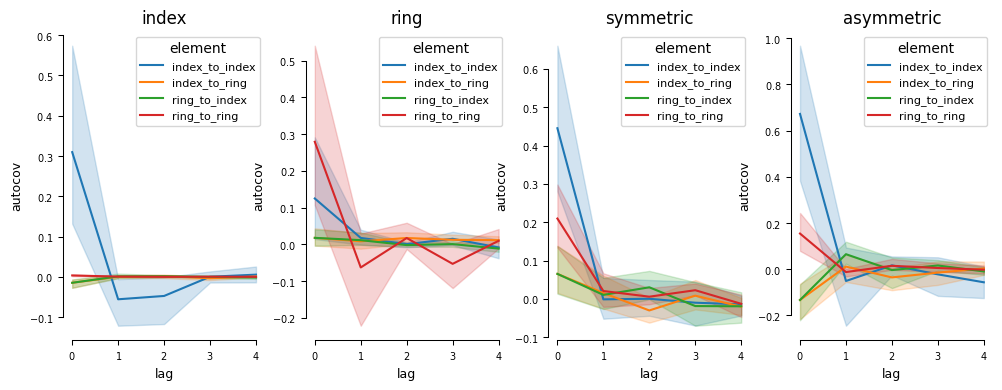

In [16]:
cov_cols = ['index_to_index', 'index_to_ring', 'ring_to_index', 'ring_to_ring']
chord_types = ['index', 'ring', 'symmetric', 'asymmetric']

melted = auto_covs_grouped.melt(
    id_vars=['subNum', 'chord_type', 'lag'],
    value_vars=cov_cols,
    var_name='element',
    value_name='autocov',
)

fig, axs = plt.subplots(1, 4, figsize=(12, 4))

for ax, chord_type in zip(axs, chord_types):
    if chord_type == 'asymmetric':
        # print(melted[(melted['chord_type'] == chord_type) & (melted['lag'] == 0)])
        # ignore subnum 4 (high variance)
        sns.lineplot(data=melted[melted['chord_type'] == chord_type][melted['subNum'] != 4], x='lag', y='autocov', hue='element', ax=ax)
    else:
        sns.lineplot(data=melted[melted['chord_type'] == chord_type], x='lag', y='autocov', hue='element', ax=ax)
    ax.set_title(chord_type)
    ax.set_xticks(range(0, lag_range))
sns.despine(trim=True)
plt.show()


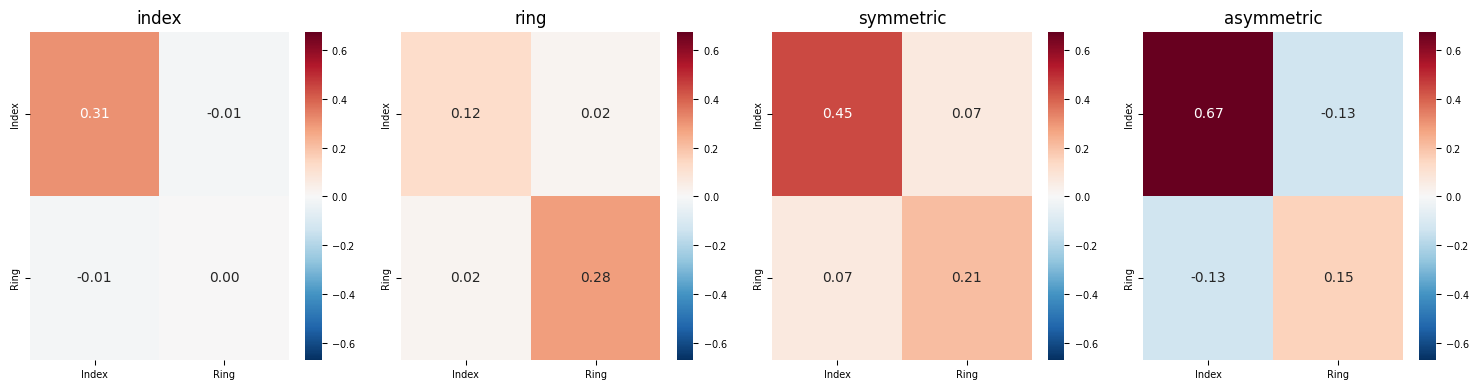

In [17]:
import numpy as np

cov_cols = ['index_to_index', 'index_to_ring', 'ring_to_index', 'ring_to_ring']
chord_types = ['index', 'ring', 'symmetric', 'asymmetric']

# Filter for lag 0 only
auto_covs_lag0 = auto_covs_grouped[auto_covs_grouped['lag'] == 0]

# Compute color scale limits from all heatmap values across types
heatmaps = []
for chord_type in chord_types:
    df = auto_covs_lag0[auto_covs_lag0['chord_type'] == chord_type]
    if chord_type == 'asymmetric':
        df = df[df['subNum'] != 4]
    cov = df[cov_cols].mean()
    heatmaps.append(np.array([
        [cov['index_to_index'], cov['index_to_ring']],
        [cov['ring_to_index'], cov['ring_to_ring']],
    ]))

absmax = np.nanmax(np.abs(heatmaps))

fig, axs = plt.subplots(1, 4, figsize=(15, 4))
for ax, chord_type, heatmap_data in zip(axs, chord_types, heatmaps):
    sns.heatmap(heatmap_data, vmin=-absmax, vmax=absmax, ax=ax, cmap = 'RdBu_r', annot = True, fmt = '.2f')
    ax.set_xticks([0.5, 1.5], labels = ['Index', 'Ring'])
    ax.set_yticks([0.5, 1.5], labels = ['Index', 'Ring'])
    ax.set_title(chord_type)
plt.tight_layout()
plt.show()


### All fingers

In [18]:
def auto_cov_all_fingers(data : pd.DataFrame, lag_range : int = 5):
    """
    Calculate the auto-covariance of the data.

    Args: 
        data: pd.DataFrame with columns 'TN' and 'chord' and 'endForce'

    Returns:
        auto-covariance of the data
    """


    sub_num = data['subNum'].iloc[0]
    chord_type = data['chord_type'].iloc[0]
    auto_covs = []
    for chord, chord_data in data.groupby('chord'):
        # print(chord)
        for lag in range(0, lag_range):
            # print(lag)
            # sort by TN
            chord_data = chord_data.sort_values('TN')
            forces = chord_data[[f'endForce{i}' for i in [1, 2, 3, 4, 5]]].values
            auto_cov = manual_autocovariance(forces, lag)
            # print(auto_cov)
            auto_covs.append({
                'subNum': sub_num,
                'chord_type': chord_type,
                'chord': chord,
                'lag': lag,
                '1_to_1': auto_cov[0, 0],
                '1_to_2': auto_cov[0, 1],
                '1_to_3': auto_cov[0, 2],
                '1_to_4': auto_cov[0, 3],
                '1_to_5': auto_cov[0, 4],
                '2_to_1': auto_cov[1, 0],
                '2_to_2': auto_cov[1, 1],
                '2_to_3': auto_cov[1, 2],
                '2_to_4': auto_cov[1, 3],
                '2_to_5': auto_cov[1, 4],
                '3_to_1': auto_cov[2, 0],
                '3_to_2': auto_cov[2, 1],
                '3_to_3': auto_cov[2, 2],
                '3_to_4': auto_cov[2, 3],
                '3_to_5': auto_cov[2, 4],
                '4_to_1': auto_cov[3, 0],
                '4_to_2': auto_cov[3, 1],
                '4_to_3': auto_cov[3, 2],
                '4_to_4': auto_cov[3, 3],
                '4_to_5': auto_cov[3, 4],
                '5_to_1': auto_cov[4, 0],
                '5_to_2': auto_cov[4, 1],
                '5_to_3': auto_cov[4, 2],
                '5_to_4': auto_cov[4, 3],
                '5_to_5': auto_cov[4, 4],
                
            })
    auto_covs = pd.DataFrame(auto_covs)
    return auto_covs



In [19]:
vector_auto_covs = []
lag_range = 1
for subnum, sub_data in unpurturbed_blocks.groupby('subNum'):
    for chord_type, chord_data in sub_data.groupby('chord_type'):
        # print(chord_type)
        auto_covs = auto_cov_all_fingers(chord_data, lag_range)
        vector_auto_covs.append(auto_covs)

vector_auto_covs = pd.concat(vector_auto_covs)

In [20]:
auto_covs_grouped_all_fingers = vector_auto_covs.groupby(['subNum', 'chord_type', 'lag']).agg({
    '1_to_1': 'mean',
    '1_to_2': 'mean',
    '1_to_3': 'mean',
    '1_to_4': 'mean',
    '1_to_5': 'mean',
    '2_to_1': 'mean',
    '2_to_2': 'mean',
    '2_to_3': 'mean',
    '2_to_4': 'mean',
    '2_to_5': 'mean',
    '3_to_1': 'mean',
    '3_to_2': 'mean',
    '3_to_3': 'mean',
    '3_to_4': 'mean',
    '3_to_5': 'mean',
    '4_to_1': 'mean',
    '4_to_2': 'mean',
    '4_to_3': 'mean',
    '4_to_4': 'mean',
    '4_to_5': 'mean',
    '5_to_1': 'mean',
    '5_to_2': 'mean',
    '5_to_3': 'mean',
    '5_to_4': 'mean',
    '5_to_5': 'mean',
}).reset_index()

In [21]:
auto_covs_grouped_all_fingers

,subNum,chord_type,lag,1_to_1,1_to_2,1_to_3,1_to_4,1_to_5,2_to_1,2_to_2,...,4_to_1,4_to_2,4_to_3,4_to_4,4_to_5,5_to_1,5_to_2,5_to_3,5_to_4,5_to_5
0,2,asymmetric,0,0.010945,0.008810,-0.031368,0.006072,-0.000303,0.008810,0.184900,...,0.006072,-0.054274,-0.117718,0.172516,-0.004851,-0.000303,-0.002294,-0.020955,-0.004851,0.018677
1,2,index,0,0.006807,0.007720,0.001675,0.000784,0.000300,0.007720,0.113498,...,0.000784,-0.003760,0.000277,0.000621,0.000050,0.000300,0.001181,0.000473,0.000050,0.000478
2,2,ring,0,0.003677,-0.004028,-0.003044,0.004184,0.000305,-0.004028,0.038241,...,0.004184,-0.007728,0.014872,0.059039,0.004958,0.000305,0.001260,0.001592,0.004958,0.001671
3,2,symmetric,0,0.006463,-0.003845,-0.011008,-0.004520,0.000505,-0.003845,0.201738,...,-0.004520,0.046527,-0.030344,0.130405,0.013895,0.000505,0.000713,-0.008034,0.013895,0.007211
4,3,asymmetric,0,0.128249,-0.091855,0.094463,-0.004490,0.020899,-0.091855,0.769437,...,-0.004490,-0.296636,-0.225345,0.328545,0.000177,0.020899,-0.040214,0.020253,0.000177,0.015919
5,3,index,0,0.009292,-0.048071,0.002282,0.002293,0.001224,-0.048071,1.015206,...,0.002293,-0.050379,0.002947,0.008582,0.000774,0.001224,-0.011170,-0.000132,0.000774,0.000596
6,3,ring,0,0.016576,0.001833,0.000099,-0.029396,-0.003321,0.001833,0.003242,...,-0.029396,0.005785,-0.006239,0.213642,0.011236,-0.003321,0.000088,-0.000171,0.011236,0.001789
7,3,symmetric,0,0.704532,0.028675,0.202059,-0.020561,0.007907,0.028675,0.290858,...,-0.020561,0.060691,0.281083,0.150286,-0.000819,0.007907,-0.001548,0.019485,-0.000819,0.002505
8,4,asymmetric,0,0.010638,0.011807,-0.003455,-0.001763,-0.001225,0.011807,2.634245,...,-0.001763,0.163189,0.063680,0.219622,-0.006166,-0.001225,-0.058275,0.010615,-0.006166,0.011352
9,4,index,0,0.011207,-0.030535,0.002184,0.002352,0.001067,-0.030535,0.324019,...,0.002352,-0.011214,0.003799,0.002010,0.000580,0.001067,-0.004033,0.000336,0.000580,0.000557


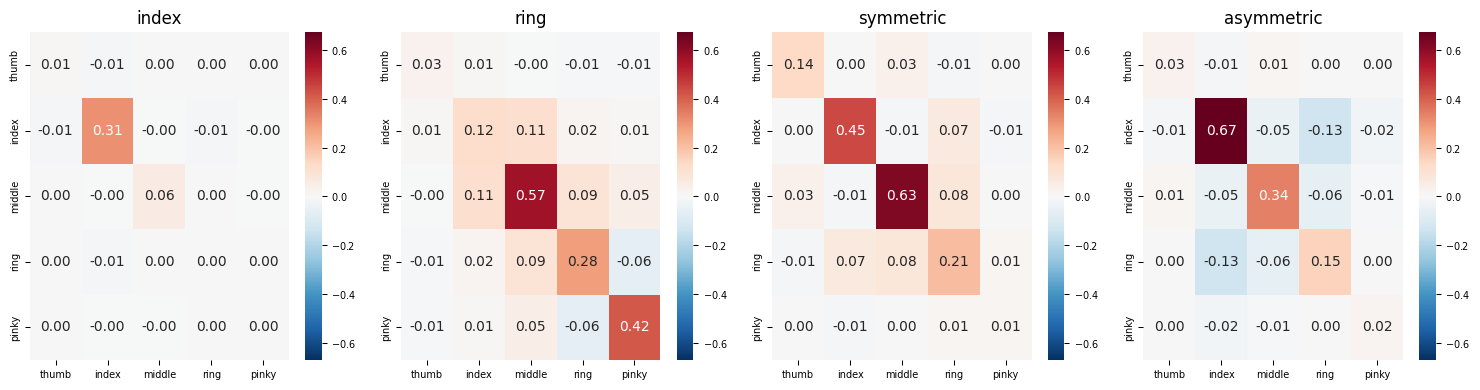

In [22]:
import numpy as np

cov_cols = ['1_to_1', '1_to_2', '1_to_3', '1_to_4', '1_to_5', '2_to_1', '2_to_2', '2_to_3', '2_to_4', '2_to_5', '3_to_1', '3_to_2', '3_to_3', '3_to_4', '3_to_5', '4_to_1', '4_to_2', '4_to_3', '4_to_4', '4_to_5', '5_to_1', '5_to_2', '5_to_3', '5_to_4', '5_to_5']
chord_types = ['index', 'ring', 'symmetric', 'asymmetric']

# Filter for lag 0 only
auto_covs_lag0 = auto_covs_grouped_all_fingers[auto_covs_grouped_all_fingers['lag'] == 0]

# Compute color scale limits from all heatmap values across types
heatmaps = []
for chord_type in chord_types:
    df = auto_covs_lag0[auto_covs_lag0['chord_type'] == chord_type]
    if chord_type == 'asymmetric':
        df = df[df['subNum'] != 4]
    cov = df[cov_cols].mean()
    # heatmaps.append(np.array([
    #     [cov['index_to_index'], cov['index_to_ring']],
    #     [cov['ring_to_index'], cov['ring_to_ring']],
    # ]))
    heatmaps.append(np.array([
        [cov['1_to_1'], cov['1_to_2'], cov['1_to_3'], cov['1_to_4'], cov['1_to_5']],
        [cov['2_to_1'], cov['2_to_2'], cov['2_to_3'], cov['2_to_4'], cov['2_to_5']],
        [cov['3_to_1'], cov['3_to_2'], cov['3_to_3'], cov['3_to_4'], cov['3_to_5']],
        [cov['4_to_1'], cov['4_to_2'], cov['4_to_3'], cov['4_to_4'], cov['4_to_5']],
        [cov['5_to_1'], cov['5_to_2'], cov['5_to_3'], cov['5_to_4'], cov['5_to_5']],
    ]))

absmax = np.nanmax(np.abs(heatmaps))

fig, axs = plt.subplots(1, 4, figsize=(15, 4))
for ax, chord_type, heatmap_data in zip(axs, chord_types, heatmaps):
    sns.heatmap(heatmap_data, vmin=-absmax, vmax=absmax, ax=ax, cmap = 'RdBu_r', annot = True, fmt = '.2f')
    # ax.set_xticks([0.5, 1.5], labels = ['Index', 'Ring'])
    # ax.set_yticks([0.5, 1.5], labels = ['Index', 'Ring'])
    ax.set_xticks(([0.5, 1.5, 2.5, 3.5, 4.5]), labels = ['thumb', 'index', 'middle', 'ring', 'pinky'])
    ax.set_yticks(([0.5, 1.5, 2.5, 3.5, 4.5]), labels = ['thumb', 'index', 'middle', 'ring', 'pinky'])
    ax.set_title(chord_type)
plt.tight_layout()
plt.show()


## purturbed Blocks

In [311]:
purturbed_block = subjs_correct[subjs_correct['block_type'] == 'purturbed'].copy()
# purturbed_block['chord_type'] = purturbed_block.apply(utils.determine_two_finger_chord_type, axis = 1)


In [312]:
vector_auto_covs = []
lag_range = 3
for subnum, sub_data in purturbed_block.groupby('subNum'):
    for chord_type, chord_data in sub_data.groupby('chord_type'):
        # print(chord_type)
        auto_covs = auto_cov(chord_data, lag_range)
        vector_auto_covs.append(auto_covs)

vector_auto_covs = pd.concat(vector_auto_covs)

In [313]:
auto_covs_grouped = vector_auto_covs.groupby(['subNum', 'chord_type', 'lag']).agg({
    'index_to_index': 'mean',
    'index_to_ring': 'mean',
    'ring_to_index': 'mean',
    'ring_to_ring': 'mean',
}).reset_index()

auto_covs_grouped

,subNum,chord_type,lag,index_to_index,index_to_ring,ring_to_index,ring_to_ring
0,2,asymmetric,0,0.223183,-0.015123,-0.015123,0.195618
1,2,asymmetric,1,0.067837,0.037768,0.016233,0.063231
2,2,asymmetric,2,0.023425,0.021268,0.000808,0.046111
3,2,index,0,0.160763,-0.000148,-0.000148,0.001666
4,2,index,1,0.037883,-0.004300,-0.002835,0.000698
5,2,index,2,0.038447,-0.002786,-0.002169,0.000631
6,2,ring,0,0.014880,-0.003307,-0.003307,0.128188
7,2,ring,1,0.000485,0.001411,-0.000424,0.024722
8,2,ring,2,0.000408,0.000834,0.003217,0.004661
9,2,symmetric,0,0.215798,0.017941,0.017941,0.130069


/var/folders/wg/16zn32014z5grhdv06dk49f00000gn/T/ipykernel_70568/4248001691.py:23: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(data=melted[melted['chord_type'] == chord_type][melted['subNum'] != 4], x='lag', y='autocov', hue='element', ax=ax)


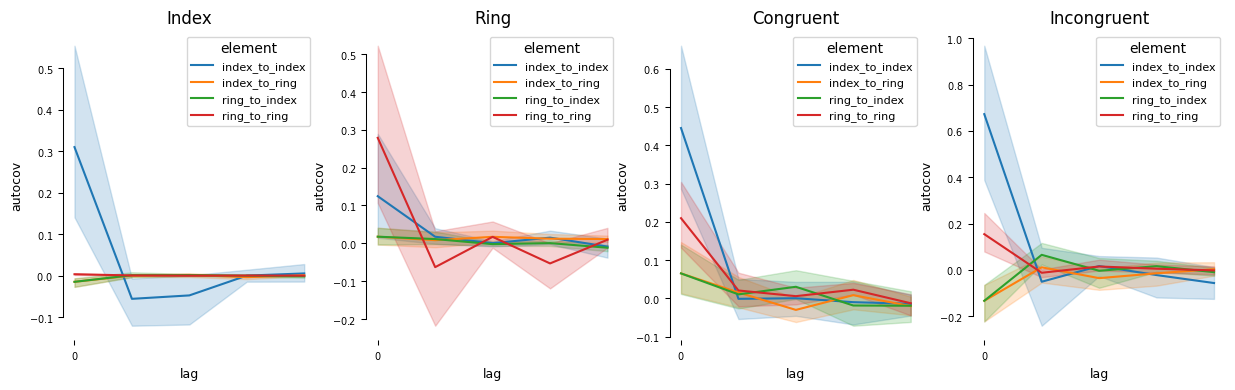

In [23]:
cov_cols = ['index_to_index', 'index_to_ring', 'ring_to_index', 'ring_to_ring']
chord_types = ['index', 'ring', 'symmetric', 'asymmetric']
chord_type_names = {
    'index': 'Index',
    'ring': 'Ring',
    'symmetric': 'Congruent',
    'asymmetric': 'Incongruent',
}

melted = auto_covs_grouped.melt(
    id_vars=['subNum', 'chord_type', 'lag'],
    value_vars=cov_cols,
    var_name='element',
    value_name='autocov',
)

fig, axs = plt.subplots(1, 4, figsize=(15, 4))

for ax, chord_type in zip(axs, chord_types):
    if chord_type == 'asymmetric':
        # print(melted[(melted['chord_type'] == chord_type) & (melted['lag'] == 0)])
        # ignore subnum 4 (high variance)
        sns.lineplot(data=melted[melted['chord_type'] == chord_type][melted['subNum'] != 4], x='lag', y='autocov', hue='element', ax=ax)
    else:
        sns.lineplot(data=melted[melted['chord_type'] == chord_type], x='lag', y='autocov', hue='element', ax=ax)
    ax.set_title(chord_type_names[chord_type])
    ax.set_xticks(range(0, lag_range))
sns.despine(trim=True)
plt.show()


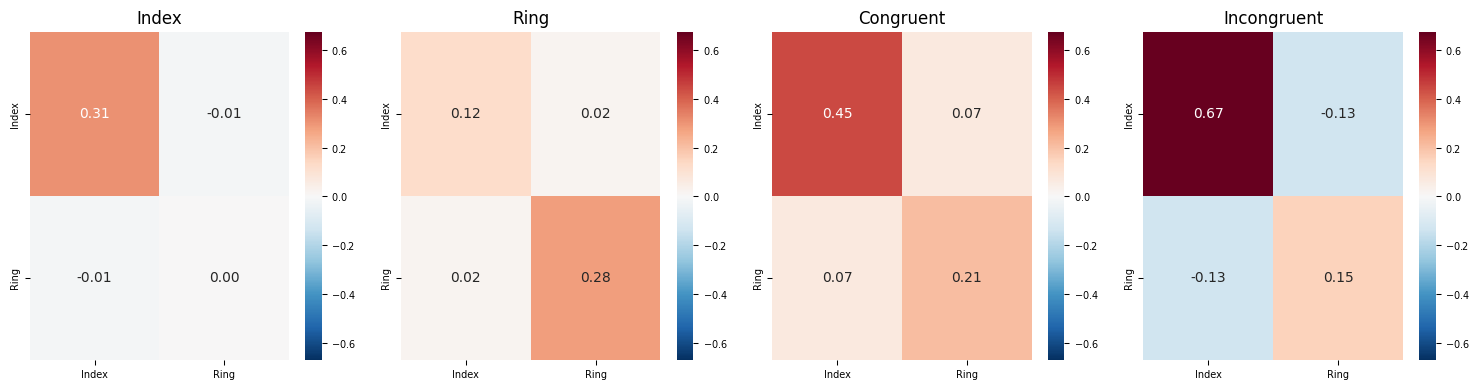

In [24]:
import numpy as np

cov_cols = ['index_to_index', 'index_to_ring', 'ring_to_index', 'ring_to_ring']
chord_types = ['index', 'ring',  'symmetric', 'asymmetric']
chord_type_names = {
    'index': 'Index',
    'ring': 'Ring',
    'symmetric': 'Congruent',
    'asymmetric': 'Incongruent',
}

# Filter for lag 0 only
auto_covs_lag0 = auto_covs_grouped[auto_covs_grouped['lag'] == 0]

# Compute color scale limits from all heatmap values across types
heatmaps = []
for chord_type in chord_types:
    df = auto_covs_lag0[auto_covs_lag0['chord_type'] == chord_type]
    if chord_type == 'asymmetric':
        df = df[df['subNum'] != 4]
    cov = df[cov_cols].mean()
    heatmaps.append(np.array([
        [cov['index_to_index'], cov['index_to_ring']],
        [cov['ring_to_index'], cov['ring_to_ring']],
    ]))

absmax = np.nanmax(np.abs(heatmaps))

fig, axs = plt.subplots(1, 4, figsize=(15, 4))
for ax, chord_type, heatmap_data in zip(axs, chord_types, heatmaps):
    sns.heatmap(heatmap_data, vmin=-absmax, vmax=absmax, ax=ax, cmap = 'RdBu_r', annot = True, fmt = '.2f')
    ax.set_xticks([0.5, 1.5], labels = ['Index', 'Ring'])
    ax.set_yticks([0.5, 1.5], labels = ['Index', 'Ring'])
    ax.set_title(chord_type_names[chord_type])
plt.tight_layout()
plt.show()


In [320]:
vector_auto_covs = []
lag_range = 1
for subnum, sub_data in purturbed_block.groupby('subNum'):
    for chord_type, chord_data in sub_data.groupby('chord_type'):
        print(chord_type)
        auto_covs = auto_cov_all_fingers(chord_data, lag_range)
        vector_auto_covs.append(auto_covs)

vector_auto_covs = pd.concat(vector_auto_covs)

auto_covs_grouped_all_fingers = vector_auto_covs.groupby(['subNum', 'chord_type', 'lag']).agg({
    '1_to_1': 'mean',
    '1_to_2': 'mean',
    '1_to_3': 'mean',
    '1_to_4': 'mean',
    '1_to_5': 'mean',
    '2_to_1': 'mean',
    '2_to_2': 'mean',
    '2_to_3': 'mean',
    '2_to_4': 'mean',
    '2_to_5': 'mean',
    '3_to_1': 'mean',
    '3_to_2': 'mean',
    '3_to_3': 'mean',
    '3_to_4': 'mean',
    '3_to_5': 'mean',
    '4_to_1': 'mean',
    '4_to_2': 'mean',
    '4_to_3': 'mean',
    '4_to_4': 'mean',
    '4_to_5': 'mean',
    '5_to_1': 'mean',
    '5_to_2': 'mean',
    '5_to_3': 'mean',
    '5_to_4': 'mean',
    '5_to_5': 'mean',
}).reset_index()

asymmetric
index
ring
symmetric
asymmetric
index
ring
symmetric
asymmetric
index
ring
symmetric
asymmetric
index
ring
symmetric


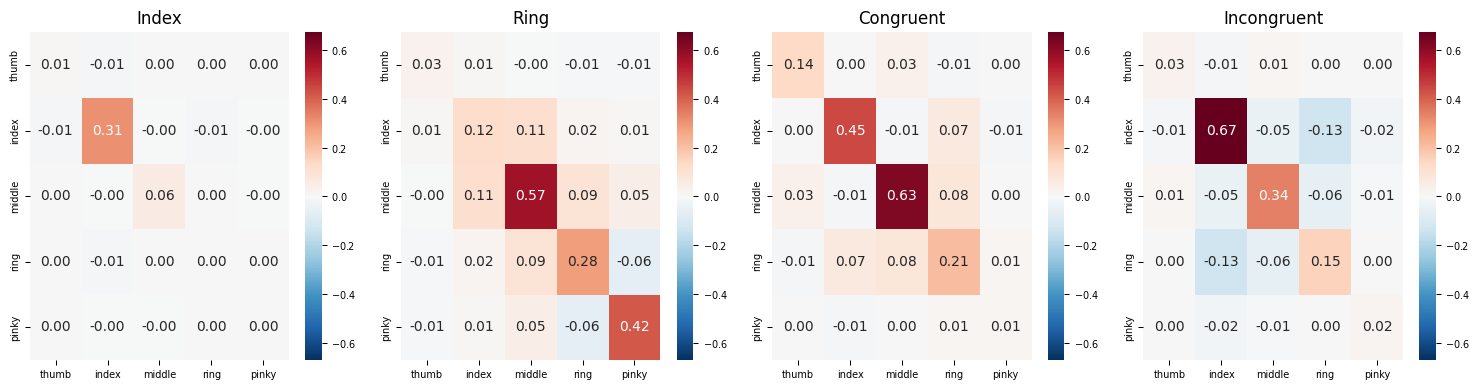

In [25]:
import numpy as np

cov_cols = ['1_to_1', '1_to_2', '1_to_3', '1_to_4', '1_to_5', '2_to_1', '2_to_2', '2_to_3', '2_to_4', '2_to_5', '3_to_1', '3_to_2', '3_to_3', '3_to_4', '3_to_5', '4_to_1', '4_to_2', '4_to_3', '4_to_4', '4_to_5', '5_to_1', '5_to_2', '5_to_3', '5_to_4', '5_to_5']
chord_types = ['index', 'ring', 'symmetric', 'asymmetric']
chord_type_names = {
    'index': 'Index',
    'ring': 'Ring',
    'symmetric': 'Congruent',
    'asymmetric': 'Incongruent',
}


# Filter for lag 0 only
auto_covs_lag0 = auto_covs_grouped_all_fingers[auto_covs_grouped_all_fingers['lag'] == 0]

# Compute color scale limits from all heatmap values across types
heatmaps = []
for chord_type in chord_types:
    df = auto_covs_lag0[auto_covs_lag0['chord_type'] == chord_type]
    if chord_type == 'asymmetric':
        df = df[df['subNum'] != 4]
    cov = df[cov_cols].mean()
    # heatmaps.append(np.array([
    #     [cov['index_to_index'], cov['index_to_ring']],
    #     [cov['ring_to_index'], cov['ring_to_ring']],
    # ]))
    heatmaps.append(np.array([
        [cov['1_to_1'], cov['1_to_2'], cov['1_to_3'], cov['1_to_4'], cov['1_to_5']],
        [cov['2_to_1'], cov['2_to_2'], cov['2_to_3'], cov['2_to_4'], cov['2_to_5']],
        [cov['3_to_1'], cov['3_to_2'], cov['3_to_3'], cov['3_to_4'], cov['3_to_5']],
        [cov['4_to_1'], cov['4_to_2'], cov['4_to_3'], cov['4_to_4'], cov['4_to_5']],
        [cov['5_to_1'], cov['5_to_2'], cov['5_to_3'], cov['5_to_4'], cov['5_to_5']],
    ]))

absmax = np.nanmax(np.abs(heatmaps))

fig, axs = plt.subplots(1, 4, figsize=(15, 4))
for ax, chord_type, heatmap_data in zip(axs, chord_types, heatmaps):
    sns.heatmap(heatmap_data, vmin=-absmax, vmax=absmax, ax=ax, cmap = 'RdBu_r', annot = True, fmt = '.2f')
    # ax.set_xticks([0.5, 1.5], labels = ['Index', 'Ring'])
    # ax.set_yticks([0.5, 1.5], labels = ['Index', 'Ring'])
    ax.set_xticks(([0.5, 1.5, 2.5, 3.5, 4.5]), labels = ['thumb', 'index', 'middle', 'ring', 'pinky'])
    ax.set_yticks(([0.5, 1.5, 2.5, 3.5, 4.5]), labels = ['thumb', 'index', 'middle', 'ring', 'pinky'])
    ax.set_title(chord_type_names[chord_type])
plt.tight_layout()
plt.show()
